In [ ]:
# Load packages
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import gseapy as gp
from scipy.sparse import issparse
from sklearn.model_selection import StratifiedKFold, train_test_split
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [2]:
# Load data
data_dir = '../data/frangieh/'
adata = sc.read_h5ad(data_dir + 'adata_preprocessed.h5ad')

In [3]:
# Feature Selection
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

# Save the HVG names
shared_hvgs = adata.var_names[adata.var["highly_variable"]]
print("Number of shared HVGs:", len(shared_hvgs))

Number of shared HVGs: 2000


In [4]:
# split data by condition
adata_control = adata[adata.obs['condition'] == 'Control']
adata_ifng = adata[adata.obs['condition'] == 'IFNγ']
adata_coculture = adata[adata.obs['condition'] == 'Co-culture']

adata_control_hvg = adata_hvg[
    adata_hvg.obs["condition"] == "Control",
    shared_hvgs
].copy()

adata_ifng_hvg = adata_hvg[
    adata_hvg.obs["condition"] == "IFNγ",
    shared_hvgs
].copy()

adata_coculture_hvg = adata_hvg[
    adata_hvg.obs["condition"] == "Co-culture",
    shared_hvgs
].copy()

In [5]:
all_data = {"control": adata_control, "ifng": adata_ifng, "coculture": adata_coculture}

## Pseudobulk and compute log fold change

In [ ]:
def compute_pseudobulk_lfc(
    adata: ad.AnnData,
    cond_key: str = 'condition',
    pert_key: str = 'perturbation',
    control_label: str = 'control',
    min_cells: int = 15,
    pseudocount: float = 1.0,
    data_type: str = 'counts',
) -> ad.AnnData:
    """
    Computes pseudobulk log2 fold changes (LFC) per perturbation relative to controls within each condition.
    
    Parameters
    ----------
    adata : ad.AnnData
        Single-cell AnnData object (log1p normalized or raw counts in .X).
    cond_key : str
        Observation key for experimental conditions (e.g., 'Control', 'IFNγ', 'Co-culture').
    pert_key : str
        Observation key for perturbation target labels.
    control_label : str
        Label indicating unperturbed control cells within pert_key.
    min_cells : int
        Minimum number of cells required per perturbation group to keep it.
    pseudocount : float
        Small offset added to linear means to prevent zero-division in log2 ratio.
    data_type : str
        Either 'counts' or 'log1p'. Specifies the type of data in adata.X.

    Returns
    -------
    ad.AnnData
        Pseudobulk AnnData object containing Log2 Fold Changes in .X,
        retained perturbation/condition metadata in .obs, and gene annotations in .var.
    """

    # 1. Clean up labels
    obs_df = adata.obs.copy()
    obs_df[pert_key] = obs_df[pert_key].astype(str).str.strip().str.lower()
    ctrl_label_clean = str(control_label).strip().lower()

    # 2. Filter perturbations with fewer than min_dataset_cells across the entire dataset
    if min_cells > 0:
        dataset_counts = obs_df[pert_key].value_counts()
        valid_dataset_perts = dataset_counts[
            dataset_counts >= min_cells
        ].index
        cell_mask = obs_df[pert_key].isin(valid_dataset_perts).values

        adata_filtered = adata[cell_mask].copy()
        obs_df = obs_df[cell_mask].copy()
    else:
        adata_filtered = adata.copy()
    
    # 3. Extract expression matrix (linearize if log1p) or use raw counts
    if data_type == "log1p":
        if issparse(adata_filtered.X):
            X_linear = adata_filtered.X.copy().astype(np.float64)
            X_linear.data = np.expm1(X_linear.data)
            X_linear.data = np.nan_to_num(
                X_linear.data, nan=0.0, posinf=0.0, neginf=0.0
            )
            X_linear.data[X_linear.data < 0] = 0.0
            X_linear.eliminate_zeros()
        else:
            X_linear = np.expm1(
                np.asarray(adata_filtered.X, dtype=np.float64)
            )
            X_linear = np.nan_to_num(X_linear, nan=0.0, posinf=0.0, neginf=0.0)
            X_linear[X_linear < 0] = 0.0
    elif data_type == "counts":
        if issparse(adata_filtered.X):
            X_linear = adata_filtered.X.copy().astype(np.float64)
            X_linear.data = np.nan_to_num(
                X_linear.data, nan=0.0, posinf=0.0, neginf=0.0
            )
            X_linear.data[X_linear.data < 0] = 0.0
            X_linear.eliminate_zeros()
        else:
            X_linear = np.asarray(adata_filtered.X, dtype=np.float64)
            X_linear = np.nan_to_num(X_linear, nan=0.0, posinf=0.0, neginf=0.0)
            X_linear[X_linear < 0] = 0.0
    else:
        X_linear = adata_filtered.X.copy()

    lfc_matrices = []
    obs_metadata_list = []

    # 4. Process each condition independently without per-condition min_cells filtering
    for cond_val, cond_obs in obs_df.groupby(cond_key):
        cond_indices = cond_obs.index
        cond_mask = obs_df.index.isin(cond_indices)

        # Extract linear matrix subset for this condition
        X_cond = X_linear[cond_mask, :]
        cond_perts = obs_df.loc[cond_indices, pert_key].values
        pert_counts_in_cond = cond_obs[pert_key].value_counts()

        # Locate control cells in this condition
        ctrl_mask = cond_perts == ctrl_label_clean
        if not np.any(ctrl_mask):
            print(
                f"Skipping condition '{cond_val}': No control cells"
                f" ('{ctrl_label_clean}') found."
            )
            continue

        # Compute mean linear profile for control
        if issparse(X_cond):
            ctrl_mean = np.asarray(X_cond[ctrl_mask, :].mean(axis=0)).ravel()
        else:
            ctrl_mean = X_cond[ctrl_mask, :].mean(axis=0)

        # Target all non-control perturbations present in this condition
        target_perts = [
            p for p in np.unique(cond_perts) if p != ctrl_label_clean
        ]

        cond_lfc_list = []
        retained_obs = []

        for pert in target_perts:
            p_mask = cond_perts == pert

            if issparse(X_cond):
                p_mean = np.asarray(X_cond[p_mask, :].mean(axis=0)).ravel()
            else:
                p_mean = X_cond[p_mask, :].mean(axis=0)

            # Calculate standard Log2 Fold Change
            lfc = np.log2((p_mean + pseudocount) / (ctrl_mean + pseudocount))
            cond_lfc_list.append(lfc)

            # Metadata tracking
            sample_obs_row = cond_obs[
                cond_obs[pert_key] == pert
            ].iloc[0].to_dict()
            sample_obs_row["n_cells_pseudobulk"] = pert_counts_in_cond[pert]
            retained_obs.append(sample_obs_row)

        if len(cond_lfc_list) > 0:
            lfc_matrices.append(np.vstack(cond_lfc_list))
            obs_metadata_list.extend(retained_obs)

    if not lfc_matrices:
        raise ValueError(
            "No valid perturbation groups could be computed across conditions."
        )

    # 5. Concatenate and return AnnData
    final_lfc_matrix = np.vstack(lfc_matrices)
    final_obs_df = pd.DataFrame(obs_metadata_list)
    final_obs_df.index = [
        f"{row[cond_key]}_{row[pert_key]}" for row in obs_metadata_list
    ]

    lfc_adata = ad.AnnData(
        X=final_lfc_matrix, obs=final_obs_df, var=adata_filtered.var.copy()
    )
    lfc_adata.uns["lfc_baseline_label"] = control_label
    lfc_adata.uns["pseudocount"] = pseudocount

    return lfc_adata

# All condition

In [ ]:
adata_hvg_lfc = compute_pseudobulk_lfc(
    adata=adata_hvg,
    cond_key='condition',
    pert_key='perturbation',
    control_label='control',
    min_cells=15,
    pseudocount=1.0,
    data_type='counts'
)

## Select Pertrubations and Test/Train Split

Ideas for splitting:
- A. 50 perturbations with highest cell counts
- B. random split
- C. 50 perturbations with highest lfc
- D. cluster and choose representatives from each cluster
- E. Select perturbations with the most occurences in the MSigDB_Hallmark_2020 database pathways

### (a) most frequent and (b) randomly

In [8]:
pertubation_counts = adata.obs[adata.obs['perturbation'] != 'control']['perturbation'].value_counts()
print(pertubation_counts)

# select 50 pertubations: (a) most frequent pertubations, (b) randomly

# (a)
top50_pertubations = pertubation_counts.head(50).index.tolist()

# (b)
np.random.seed(42)
all_pertubations = pertubation_counts.index.tolist()
random50_pertubations = list(np.random.choice(all_pertubations, size=50, replace=False))

perturbation
ACTA2      1201
B2M        1135
A2M        1088
IFNGR2     1088
AEBP1      1087
           ... 
RACK1        31
PSMA7        28
UBL5         16
TUBB         11
control       0
Name: count, Length: 249, dtype: int64


### (c) select 50 pertubations according to their highest lfc

In [9]:
# (c) select 50 pertubations according to their highest lfc

# mean absolute LFC over all 2000 genes per row 
df_lfc_all = adata_hvg_lfc.to_df()
df_lfc_all['perturbation'] = adata_hvg_lfc.obs['perturbation'].values
df_lfc_all['mean_abs_lfc'] = df_lfc_all.drop(columns='perturbation').abs().mean(axis=1)

# maximal LFC per pertubation over all 3 conditions  
pert_strength = df_lfc_all.groupby('perturbation')['mean_abs_lfc'].max()

# top 50 pertubations with strongest total effect
top_lfc50_pertubations = pert_strength.sort_values(ascending=False).head(50).index.tolist()

### D. cluster and choose representatives from each cluster

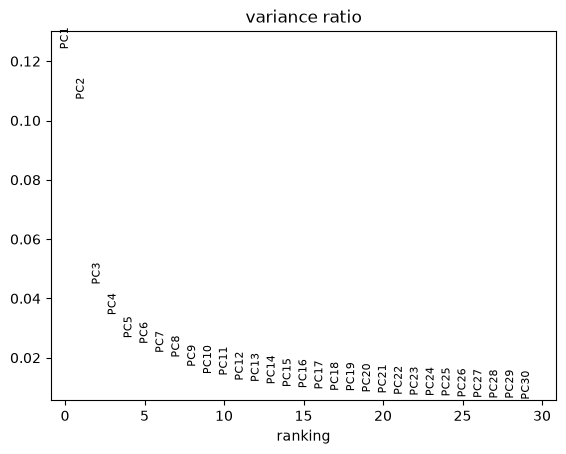

In [10]:
# Compute PCA
# Find optimal number of PCs to use for clustering using the elbow method
sc.pp.pca(adata_hvg_lfc, n_comps=30)
sc.pl.pca_variance_ratio(adata_hvg_lfc, n_pcs=30, log=False)

In [11]:
sc.pp.pca(adata_hvg_lfc, n_comps=9)

In [12]:
sc.pp.neighbors(adata_hvg_lfc)
sc.tl.leiden(adata_hvg_lfc, resolution=0.55
)

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_277720/2727501326.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_hvg_lfc, resolution=0.55


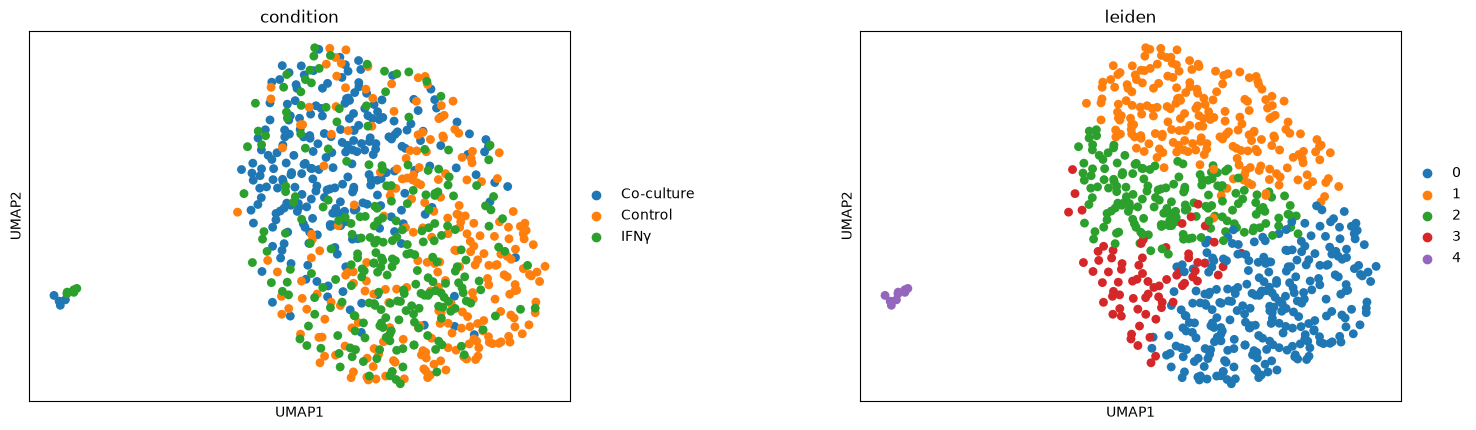

In [13]:
sc.tl.umap(adata_hvg_lfc)
sc.pl.umap(adata_hvg_lfc, color=['condition', 'leiden'], wspace=0.4)

In [14]:
# select 10 perturbations per cluster to get 50 perturbations 
np.random.seed(42)
cluster50_perturbations = []

for cluster_id in sorted(adata_hvg_lfc.obs['leiden'].unique()):
    # get all perturbations per cluster
    cluster_perts = adata_hvg_lfc.obs[adata_hvg_lfc.obs['leiden'] == cluster_id]['perturbation'].unique().tolist()
    
    # select 10 random perturbations per cluster 
    n_samples = min(10, len(cluster_perts))
    chosen = np.random.choice(cluster_perts, size=n_samples, replace=False).tolist()
    cluster50_perturbations.extend(chosen)
    print(f"Cluster {cluster_id}: {len(chosen)} Perturbationen selected (out of {len(cluster_perts)} available ones)")

# if a cluster has less than 10 perturbations, select other perturbations to get 50 in total
if len(cluster50_perturbations) < 50:
    remaining = [p for p in adata_hvg_lfc.obs['perturbation'].unique() if p not in cluster50_perturbations]
    needed = 50 - len(cluster50_perturbations)
    cluster50_perturbations.extend(np.random.choice(remaining, size=needed, replace=False).tolist())

print(f"\ntotal selected Knockouts: {len(cluster50_perturbations)}")


Cluster 0: 10 Perturbationen selected (out of 180 available ones)
Cluster 1: 10 Perturbationen selected (out of 142 available ones)
Cluster 2: 10 Perturbationen selected (out of 134 available ones)
Cluster 3: 10 Perturbationen selected (out of 58 available ones)
Cluster 4: 5 Perturbationen selected (out of 5 available ones)

total selected Knockouts: 50


### (e) select 50 pertubations with pathway information (Deniz)
- selected pertubations should cover a lot of different pathways / should be present in different pathways
- a lot of pertubations are present in the same pathways, it would be best to select pertubations which are present in different pathways
- use MSigDB Hallmark Pathway Information

In [15]:
# load hallmark pathways 
hallmark = gp.get_library(name="MSigDB_Hallmark_2020", organism="Human")

hallmark_upper = {pathway: {str(g).upper() for g in genes} for pathway, genes in hallmark.items()}

In [16]:
valid_perts = adata_hvg_lfc.obs["perturbation"].unique().tolist()
eligible_genes = [g for g in valid_perts if g.lower() != 'control']

pathway_matrix = pd.DataFrame(0, index=eligible_genes, columns=hallmark_upper.keys(), dtype=int)
for gene in eligible_genes:
    g_up = str(gene).upper()
    for pathway, p_genes in hallmark_upper.items():
        if g_up in p_genes:
            pathway_matrix.loc[gene, pathway] = 1

In [17]:
rng = np.random.default_rng(42)
annotated_genes = pathway_matrix.index[pathway_matrix.sum(axis=1) > 0].tolist()

pathway50_pertubations = []
covered_pathways = set()
remaining = annotated_genes.copy()

while len(pathway50_pertubations) < 50 and len(remaining) > 0:
    gains = {}
    for gene in remaining:
        gene_pathways = set(pathway_matrix.columns[pathway_matrix.loc[gene] == 1])
        new_pathways = gene_pathways - covered_pathways
        gains[gene] = len(new_pathways)
        
    max_gain = max(gains.values())
    
    # if no gene is found in a new pathway, stop loop
    if max_gain == 0:
        break
        
    best_genes = [g for g, gain in gains.items() if gain == max_gain]
    chosen = rng.choice(best_genes)
    
    pathway50_pertubations.append(chosen)
    covered_pathways.update(pathway_matrix.columns[pathway_matrix.loc[chosen] == 1])
    remaining.remove(chosen)

# if < 50 Gene: fill with remaining genes
if len(pathway50_pertubations) < 50:
    extra_candidates = [g for g in eligible_genes if g not in pathway50_pertubations]
    extra = rng.choice(extra_candidates, size=50 - len(pathway50_pertubations), replace=False)
    pathway50_pertubations.extend(extra.tolist())

print(f"selected genes: {len(pathway50_pertubations)}")
print(f"covered Hallmark-pathways: {pathway_matrix.loc[pathway50_pertubations].max(axis=0).sum()} / 50")

selected genes: 50
covered Hallmark-pathways: 46 / 50


In [18]:
def select_perturbation_subset(adata, pert_list, label='Selected', control_label='control'):
    """
    Subsets AnnData to the selected perturbations + controls,
    and adds a categorical visualization column to the full adata.
    """
    # 1. Include control cells alongside the selected perturbations
    targets_with_ctrl = list(pert_list) + [control_label]
    
    # 2. Add visual indicator column to the original adata
    adata.obs['selected_subset'] = (
        adata.obs['perturbation']
        .isin(pert_list)
        .map({True: label, False: 'Not Selected'})
        .astype('category')
    )
    
    # 3. Create clean subset AnnData
    adata_sub = adata[adata.obs['perturbation'].isin(targets_with_ctrl)].copy()
    
    return adata_sub, adata


def plot_perturbation_subset(adata_full, adata_sub, label_name='Selected', color_by='condition'):
    """Plots Leiden/Condition on the subset and selected cells on the full dataset."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Subset embedding colored by condition or cluster
    sc.pl.umap(
        adata_sub, 
        color=color_by, 
        ax=ax1, 
        show=False, 
        title=f'Subset UMAP ({color_by})'
    )
    
    # Right: Full dataset showing which cells were selected
    sc.pl.umap(
        adata_full, 
        color='selected_subset', 
        palette={label_name: '#e41a1c', 'Not Selected': '#d9d9d9'}, 
        ax=ax2, 
        show=False, 
        title=f'{label_name} (50 Targets)'
    )
    
    plt.tight_layout()
    plt.show()

## Train test split

In [20]:
# Add Stratification Options to the adata obs

# -------------------------------------------------------------
# 1. Annotate Pathway in adata.obs
# -------------------------------------------------------------
# Extract all pathways mapped to each gene from pathway_matrix
gene_to_pathways = {}
for gene in pathway_matrix.index:
    pathways = pathway_matrix.columns[pathway_matrix.loc[gene] == 1].tolist()
    if len(pathways) > 0:
        gene_to_pathways[gene] = "; ".join(pathways)
    else:
        gene_to_pathways[gene] = "Unannotated"

# Add pathway column to obs
adata_hvg_lfc.obs["pathway"] = (
    adata_hvg_lfc.obs["perturbation"]
    .map(gene_to_pathways)
    .fillna("Control / Non-targeting")
    .astype("category")
)

# -------------------------------------------------------------
# 2. Annotate LFC Magnitude Tier in adata.obs
# -------------------------------------------------------------
# Bin mean absolute LFC into 3 tiers (Low, Medium, High)
lfc_tiers = pd.qcut(
    df_lfc_all['mean_abs_lfc'],
    q=3,
    labels=["Low LFC", "Medium LFC", "High LFC"]
)

# Add lfc_magnitude_tier column to obs
adata_hvg_lfc.obs["lfc_magnitude_tier"] = (
    adata_hvg_lfc.obs["perturbation"]
    .map(lfc_tiers.to_dict())
    .fillna("Control")
    .astype("category")
)

In [41]:
def prepare_perturbation_split(
    adata,
    pert_list: list,
    stratify_col: str = None,
    pert_col: str = "perturbation",
    test_size: float = 0.2,
    random_state: int = 42,
):
    """Split AnnData into perturbation-level train/val/test subsets.

    The split is performed on unique perturbation targets, then
    expanded back to rows in ``adata``.
    """
    if pert_col not in adata.obs.columns:
        raise KeyError(f"Column '{pert_col}' not found in adata.obs")
    if not 0 < test_size < 1:
        raise ValueError(f"test_size must be in (0, 1), got {test_size}")

    # Build a normalized metadata table decoupled from AnnData view semantics.
    obs_norm = adata.obs.copy()
    obs_norm[pert_col] = obs_norm[pert_col].astype(str).str.strip().str.lower()

    selected_perts = {str(p).strip().lower() for p in pert_list if pd.notna(p)}
    control_label = "control"
    if control_label in set(obs_norm[pert_col].values):
        selected_perts.add(control_label)

    keep_mask = obs_norm[pert_col].isin(selected_perts)
    obs_sel = obs_norm.loc[keep_mask].copy()
    sub_adata = adata[keep_mask.values].copy()

    # Keep normalized perturbation labels in subset for downstream checks.
    sub_adata.obs[pert_col] = obs_sel[pert_col].values

    # Unique non-control perturbations.
    non_control = obs_sel[obs_sel[pert_col] != control_label]
    perts = non_control[pert_col].drop_duplicates().to_numpy()

    if len(perts) == 0:
        adata_unique_perts = sorted(pd.unique(obs_norm[pert_col]))
        requested_preview = sorted(list(selected_perts - {control_label}))[:10]
        available_preview = adata_unique_perts[:10]
        raise ValueError(
            "No non-control perturbations matched between `pert_list` and `adata`. "
            "Check label formatting/casing. "
            f"Example requested: {requested_preview}; "
            f"example available: {available_preview}"
        )

    # Build perturbation-level table for splitting.
    pert_meta = non_control[[pert_col]].drop_duplicates().set_index(pert_col)

    strat_labels = None
    if stratify_col:
        if stratify_col not in obs_sel.columns:
            raise KeyError(
                f"stratify_col='{stratify_col}' not found in adata.obs"
            )

        pert_to_strat = (
            non_control[[pert_col, stratify_col]]
            .drop_duplicates(subset=[pert_col])
            .set_index(pert_col)[stratify_col]
        )
        pert_meta[stratify_col] = pert_to_strat

        candidate_labels = pert_meta[stratify_col].values
        class_counts = pd.Series(candidate_labels).value_counts()
        n_classes = int(class_counts.shape[0])
        n_samples = int(pert_meta.shape[0])
        n_test = int(np.ceil(test_size * n_samples))

        # Use stratification only when feasible.
        if n_classes >= 2 and class_counts.min() >= 2 and n_test >= n_classes:
            strat_labels = candidate_labels
        else:
            print(n_classes, class_counts.min(), n_test)
            print(
                "Warning: stratified split not feasible for the current subset; "
                "falling back to random split."
            )

    train_val_perts, test_perts = train_test_split(
        perts,
        test_size=test_size,
        stratify=strat_labels,
        random_state=random_state,
    )

    train_val_strat = None
    if strat_labels is not None:
        train_val_strat = pert_meta.loc[train_val_perts, stratify_col].values
        tv_counts = pd.Series(train_val_strat).value_counts()
        n_tv_classes = int(tv_counts.shape[0])
        n_val = int(np.ceil(0.25 * len(train_val_perts)))
        if tv_counts.min() < 2 or n_val < n_tv_classes:
            train_val_strat = None

    train_perts, val_perts = train_test_split(
        train_val_perts,
        test_size=0.25,  # 0.25 of 0.80 -> 0.20 val / 0.60 train / 0.20 test
        stratify=train_val_strat,
        random_state=random_state,
    )

    # Row-level partition by perturbation assignments.
    sub_perts = sub_adata.obs[pert_col]
    is_train = sub_perts.isin(train_perts)
    is_val = sub_perts.isin(val_perts)
    is_test = sub_perts.isin(test_perts)

    return (
        sub_adata[is_train].copy(),
        sub_adata[is_val].copy(),
        sub_adata[is_test].copy(),
    )

In [43]:
adata_hvg_lfc.obs[adata_hvg_lfc.obs["leiden"] == 4]["perturbation"].value_counts()

perturbation
a2m       0
acsl3     0
acta2     0
aebp1     0
aga       0
         ..
vat1      0
vdac2     0
wbp2      0
wnt7a     0
xage1a    0
Name: count, Length: 246, dtype: int64

In [42]:
adata_train, adata_val, adata_test= prepare_perturbation_split(
    adata=adata_hvg_lfc,
    pert_list=random50_pertubations,
    stratify_col="leiden",
    test_size=0.2,
    random_state=42,
)


5 0 10


## Predict the log2 fold change

In [ ]:
# Task: Predict log2 fold changes for perturbations
#
# INPUT:
# A. basline expression of the perturbed gene in the control condition
# B. one hot encoded vector with pathway-level information for the perturbed gene + on hot encoded condition information
# C. Gene embeddings from a pre-trained foundation model
# D. CITE-seq MOFA embeddings
#
# Learning algrithm: 
# A. Random Forest Regressor
# B. Ridge Regression
# C. GEARS perturbation prediction model
# D. (KNN, lasso)
#
# Controls:
# Negative:
# No Change: Constant prediction of zero (∆ ̂= 0)
# Train Mean: Average expression change of training perturbations
# Random: Uniform random numbers (0 to 1) as dummy embeddings
#
# Idealized:
# Global PCA on all perturbations (data leakage)
# 
# OUTPUT:
# Mean log2 fold-change profile across 2,000 genes
#
# DATA SPLIT:
#   40 unique perturbations for training
#   10 unique perturbations for testing

## Feature Engineering ($X$) & Target Matrix ($Y$)

In [5]:
## load data
# Single-cell-data 
adata_pre = sc.read_h5ad('../data/frangieh/adata_preprocessed.h5ad')

# LFC data (711 rows x 2000 HVGs)
adata_lfc = sc.read_h5ad('../data/frangieh/log_fold_change_adata_hvg.h5ad')

### Feuture Engineering Stratagy A: baseline expression

In [7]:
# calculate basal expression profile from control cells (pertubation = control in each of the 3 conditions)
ctrl_cells = adata_pre[adata_pre.obs['perturbation'] == 'control']

df_ctrl = ctrl_cells.to_df()
df_ctrl['condition'] = ctrl_cells.obs['condition'].values

# mean basal expression per condition (3 rows x ~18.000 genes)
mean_ctrl_by_cond = df_ctrl.groupby('condition').mean()

In [ ]:
# create feature matrix X
# Feature 1: Basale KO-Expression for each row
basal_ko_values = []
for _, row in adata_lfc.obs.iterrows():
    cond = row['condition']
    ko_gene = row['perturbation']
    
    # Wert abfragen (Fallback 0.0 falls nicht in Matrix vorhanden)
    val = mean_ctrl_by_cond.loc[cond, ko_gene] if ko_gene in mean_ctrl_by_cond.columns else 0.0
    basal_ko_values.append(val)

# Feature 2: Condition One-Hot-Encoding
cond_dummies = pd.get_dummies(adata_lfc.obs['condition'], dtype=float)

# Shape: 711 rows x 4 columns
X_features = np.column_stack([basal_ko_values, cond_dummies.values])

feature_names = ['basal_ko_expression'] + list(cond_dummies.columns)

In [ ]:
# scale features 
scaler = StandardScaler()
X = scaler.fit_transform(X_features)

# target matrix y: LFCs of 2000 HVGs
y = adata_lfc.X

In [ ]:
# save features 
adata_lfc.obsm['X_basal'] = X
adata_lfc.uns['feature_names_basal'] = feature_names


print(f"X (Features) Shape: {X.shape}")  # expected: (711, 4)
print(f"y (Targets)  Shape: {y.shape}")  # expected: (711, 2000)
print(f"used Feature-names: {feature_names}")

In [ ]:
all_results = []
conditions = ['Control', 'IFNγ', 'Co-culture']

for strategy_name, selected_50 in adata_lfc.uns['subsets'].items():
  # filter 50 genes and 40/10 split
  adata_50 = adata_lfc[adata_lfc.obs['perturbation'].isin(selected_50)].copy()

  np.random.seed(42)
  test_genes_10 = np.random.choice(selected_50, size=10, replace=False).tolist()
  is_test = adata_50.obs['perturbation'].isin(test_genes_10).values

  X_50 = adata_50.obsm['X_basal']
  y_50 = adata_50.X

  X_train, y_train = X_50[~is_test], y_50[~is_test]
  X_test, y_test = X_50[is_test], y_50[is_test]
  obs_test = adata_50.obs[is_test].reset_index(drop=True)

  # fit models 
  # (A) Baseline
  dummy = DummyRegressor(strategy='mean')
  dummy.fit(X_train, y_train)
  y_pred_dummy = dummy.predict(X_test)

  # (B) Ridge Regression 
  ridge = Ridge(alpha=1.0)
  ridge.fit(X_train, y_train)
  y_pred_ridge = ridge.predict(X_test)

  # (C) Random Forest 
  rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
  rf.fit(X_train, y_train)
  y_pred_rf = rf.predict(X_test)

  # metrices
  for cond in conditions:
    cond_mask = (obs_test['condition'] == cond).values
    y_true_cond = y_test[cond_mask]

    # MSE
    mse_dummy = mean_squared_error(y_true_cond, y_pred_dummy[cond_mask])
    mse_ridge = mean_squared_error(y_true_cond, y_pred_ridge[cond_mask])
    mse_rf = mean_squared_error(y_true_cond, y_pred_rf[cond_mask])

    # Pearson Korrelation
    corr_dummy = np.nanmean([
        pearsonr(y_true_cond[i], y_pred_dummy[cond_mask][i])[0]
        for i in range(len(y_true_cond))
    ])
    corr_ridge = np.nanmean([
        pearsonr(y_true_cond[i], y_pred_ridge[cond_mask][i])[0]
        for i in range(len(y_true_cond))
    ])
    corr_rf = np.nanmean([
        pearsonr(y_true_cond[i], y_pred_rf[cond_mask][i])[0]
        for i in range(len(y_true_cond))
    ])

    all_results.append({
        'Strategy': strategy_name,
        'Condition': cond,
        'MSE Baseline': mse_dummy,
        'MSE Ridge': mse_ridge,
        'MSE RF': mse_rf,
        'Pearson r Baseline': 0.0 if np.isnan(corr_dummy) else corr_dummy,
        'Pearson r Ridge': corr_ridge,
        'Pearson r RF': corr_rf,
    })

df_all_results = pd.DataFrame(all_results)
df_all_results

In [ ]:
## visualization

df_pearson = df_all_results.melt(
    id_vars=['Strategy', 'Condition'],
    value_vars=['Pearson r Baseline', 'Pearson r Ridge', 'Pearson r RF'],
    var_name='Model',
    value_name='Pearson_r',
)
df_pearson['Model'] = df_pearson['Model'].str.replace('Pearson r ', '')

df_mse = df_all_results.melt(
    id_vars=['Strategy', 'Condition'],
    value_vars=['MSE Baseline', 'MSE Ridge', 'MSE RF'],
    var_name='Model',
    value_name='MSE',
)
df_mse['Model'] = df_mse['Model'].str.replace('MSE ', '')

sns.set_theme(style='whitegrid', font_scale=1.1)

g1 = sns.catplot(
    data=df_pearson,
    x='Strategy',
    y='Pearson_r',
    hue='Model',
    col='Condition',
    kind='bar',
    palette='Set2',
    height=4,
    aspect=1.2,
)
g1.set_axis_labels('Selection Strategy', 'Mean Pearson Correlation (r)')
g1.set_titles(col_template='Condition: {col_name}')
g1.set_xticklabels(rotation=45, ha='right')
g1.fig.subplots_adjust(top=0.8)
g1.fig.suptitle('Perturbation Prediction: Pearson Correlation by Condition')
plt.show()

g2 = sns.catplot(
    data=df_mse,
    x='Strategy',
    y='MSE',
    hue='Model',
    col='Condition',
    kind='bar',
    palette='Set2',
    height=4,
    aspect=1.2,
)
g2.set_axis_labels('Selection Strategy', 'Mean Squared Error (MSE)')
g2.set_titles(col_template='Condition: {col_name}')
g2.set_xticklabels(rotation=45, ha='right')
g2.fig.subplots_adjust(top=0.8)
g2.fig.suptitle('Perturbation Prediction: MSE by Condition')
plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# --- Feature Strategy 1: Target Gene Baseline Expression (Simplistic / Baseline Model) ---
# Retrieve mean expression of the knocked-out gene in unperturbed control cells
control_cells = adata[adata.obs["perturbation"] == "control"]
ctrl_expr_mean = pd.Series(
    (
        np.asarray(control_cells.X.mean(axis=0)).ravel()
        if issparse(control_cells.X)
        else control_cells.X.mean(axis=0)
    ),
    index=adata.var_names,
)


def get_feature_matrix_baseline(pbulk_adata):
    # Condition one-hot
    ohe = OneHotEncoder(sparse_output=False)
    cond_ohe = ohe.fit_transform(pbulk_adata.obs[["condition"]])

    # Target gene baseline control expression
    target_baseline = np.array(
        [
            ctrl_expr_mean.get(pert.upper(), 0.0)
            for pert in pbulk_adata.obs["perturbation"]
        ]
    ).reshape(-1, 1)

    X = np.hstack([cond_ohe, target_baseline])
    return X, ohe


# --- Feature Strategy 2: Pretrained Embeddings / Pathway Embeddings (Advanced Models) ---
# Option 2A: Random / Node2Vec / String Embeddings (Mocked as 64-dim dense representation)
np.random.seed(42)
gene_embeddings_dict = {
    gene: np.random.normal(0, 1, size=64) for gene in selected_perturbations
}


def get_feature_matrix_embeddings(pbulk_adata, ohe_encoder):
    cond_ohe = ohe_encoder.transform(pbulk_adata.obs[["condition"]])
    gene_embeds = np.array(
        [
            gene_embeddings_dict[pert]
            for pert in pbulk_adata.obs["perturbation"]
        ]
    )
    X = np.hstack([cond_ohe, gene_embeds])
    return X


# Construct Train and Test Feature/Target Arrays
X_train_base, cond_encoder = get_feature_matrix_baseline(adata_train)
X_test_base, _ = get_feature_matrix_baseline(adata_test)

X_train_embed = get_feature_matrix_embeddings(adata_train, cond_encoder)
X_test_embed = get_feature_matrix_embeddings(adata_test, cond_encoder)

Y_train = adata_train.X.copy()
Y_test = adata_test.X.copy()

## Model Training (4 Model Types & Baselines)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    # 1. Deliberately Simplistic Baseline (Target Baseline Expr + Ridge)
    "Baseline_Ridge": Ridge(alpha=1.0),
    # 2. Linear Regularized Model on Embeddings
    "Embed_Ridge": Ridge(alpha=10.0),
    # 3. Non-Linear Tree Ensemble on Embeddings
    "Embed_RandomForest": RandomForestRegressor(
        n_estimators=100, max_depth=8, random_state=42, n_jobs=-1
    ),
    # 4. K-Nearest Neighbors on Embeddings
    "Embed_KNN": KNeighborsRegressor(n_neighbors=5, weights="distance"),
}

predictions = {}

# Train Model 1 (Baseline features)
models["Baseline_Ridge"].fit(X_train_base, Y_train)
predictions["Baseline_Ridge"] = models["Baseline_Ridge"].predict(X_test_base)

# Train Models 2-4 (Embedding features)
for name in ["Embed_Ridge", "Embed_RandomForest", "Embed_KNN"]:
    models[name].fit(X_train_embed, Y_train)
    predictions[name] = models[name].predict(X_test_embed)

# --- Negative Controls ---
# Control A: Zero Change (Delta = 0)
predictions["Control_Zero"] = np.zeros_like(Y_test)

# Control B: Train Mean Profile (Average training delta)
predictions["Control_TrainMean"] = np.tile(Y_train.mean(axis=0), (len(Y_test), 1))

In [ ]:
from scipy.stats import pearsonr


def compute_conformal_intervals(model, X_train, Y_train, X_test, alpha=0.10):
    """Calibrates non-conformity scores on training split to produce (1-alpha) prediction bands."""
    # Compute in-sample absolute residuals as non-conformity scores
    train_preds = model.predict(X_train)
    abs_residuals = np.abs(Y_train - train_preds)

    # 90th percentile error per gene (or globally)
    q_hat = np.quantile(abs_residuals, 1 - alpha, axis=0)

    test_preds = model.predict(X_test)
    lower_bound = test_preds - q_hat
    upper_bound = test_preds + q_hat

    # Calculate empirical coverage on test set
    coverage = np.mean((Y_test >= lower_bound) & (Y_test <= upper_bound))

    return test_preds, lower_bound, upper_bound, coverage


pred_rf, ci_low, ci_high, rf_coverage = compute_conformal_intervals(
    models["Embed_RandomForest"], X_train_embed, Y_train, X_test_embed
)

print(
    f"Random Forest Conformal 90% Interval Test Coverage: {rf_coverage * 100:.2f}%"
)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


def evaluate_predictions(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    # Mean Pearson correlation per perturbation profile
    pearsons = []
    for i in range(len(y_true)):
        r, _ = pearsonr(y_true[i], y_pred[i])
        pearsons.append(0.0 if np.isnan(r) else r)
    mean_pearson = np.mean(pearsons)

    # Top-50 DE Gene Recall
    recalls = []
    for i in range(len(y_true)):
        top_true = np.argsort(np.abs(y_true[i]))[-50:]
        top_pred = np.argsort(np.abs(y_pred[i]))[-50:]
        recall = len(set(top_true).intersection(set(top_pred))) / 50.0
        recalls.append(recall)
    mean_top50_recall = np.mean(recalls)

    return {
        "MSE": mse,
        "MAE": mae,
        "Mean Pearson r": mean_pearson,
        "Top-50 DE Recall": mean_top50_recall,
    }


results = []
for model_name, y_pred in predictions.items():
    metrics = evaluate_predictions(Y_test, y_pred)
    metrics["Model"] = model_name
    results.append(metrics)

results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("Mean Pearson r", ascending=False)
)
print(results_df.round(4))